In [1]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import random

In [2]:
load_dotenv()
your_llm = ChatOpenAI(model="gpt-4o-mini")

In [3]:
def random_number(x: int) -> int:
    """
    Generate a random number between 1 and x
    """
    return random.randint(1, x)

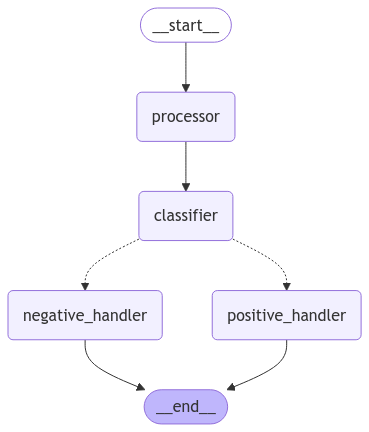

In [4]:
from agentic_framework.nodes import AgentNode, DecisionNode
from agentic_framework.graph import AgenticGraph
from agentic_framework.state import AgenticState
from copy import deepcopy

# Create nodes
agent = AgentNode(
    name="processor",
    llm=your_llm,  # Your language model instance
    node_prompt="Process the input and provide a detailed response"
)
agent.bind_tools([random_number])

decision = DecisionNode(
    name="classifier",
    llm=your_llm,
    node_prompt="Classify the response as either 'positive' or 'negative'",
    choices=["positive", "negative"]
)

positive_handler = AgentNode(
    name="positive_handler",
    llm=your_llm,
    node_prompt="Handle positive response"
)

negative_handler = AgentNode(
    name="negative_handler",
    llm=your_llm,
    node_prompt="Handle negative response"
)

# Connect nodes
agent > decision
decision["positive"] > positive_handler
decision["negative"] > negative_handler

# Create and build graph
graph_0 = AgenticGraph(
    state=AgenticState,
    start_node=agent,
    end_nodes={positive_handler, negative_handler}
)

graph_0

In [19]:
agent_1 = AgentNode(name="agent_1", llm=your_llm, node_prompt="แต่งกลอน 1 วรรค")
agent_2 = AgentNode(name="agent_2", llm=your_llm, node_prompt="แต่งกลอนเพิ่มอีก 1 วรรค")
agent_3 = AgentNode(name="agent_3", llm=your_llm, node_prompt="แต่งกลอนเพิ่มอีก 1 วรรค")
agent_4 = AgentNode(name="agent_4", llm=your_llm, node_prompt="รวมกลอนทั้งหมดเข้าด้วยกัน")

agent_1 > agent_2
agent_3 > agent_4

graph_0 = AgenticGraph(
    name = "graph_0",
    state=AgenticState,
    start_node=agent_1,
    end_nodes=agent_2
)

graph_1 = AgenticGraph(
    name = "graph_1",
    state=AgenticState,
    start_node=agent_3,
    end_nodes=agent_4
)

graph_0 > graph_1
graph_big = AgenticGraph(
    name = "graph_big",
    state=AgenticState,
    start_node=graph_0,
    end_nodes=graph_1
)

# graph_big


TypeError: argument of type 'AgentNode' is not iterable

In [16]:
from langchain_core.messages import HumanMessage
state_output = graph_big.invoke({
    "messages": [HumanMessage(content="การเมืองไทย")], 
    'log': []
    })
state_output['log']

['agent_1:การเมืองไทยเปลี่ยนแปลงเร็วไว  \nเสียงประชาชนก้องกังวานดัง  \nหวังความสุขสันต์ในอนาคต  \nร่วมสร้างชาติให้ยั่งยืนยง.',
 'agent_2:การเมืองไทยเปลี่ยนแปลงเร็วไว  \nเสียงประชาชนก้องกังวานดัง  \nหวังความสุขสันต์ในอนาคต  \nร่วมสร้างชาติให้ยั่งยืนยง  \n\nทุกเสียงสะท้อนจิตใจที่รอคอย  \nให้สิทธิ์ประชาชนเป็นใหญ่ในสังคม  \nร่วมมือร่วมใจพลิกโฉมหน้าประเทศ  \nสร้างสันติสุขให้ทวีคูณ.',
 'agent_3:การเมืองไทยเปลี่ยนแปลงเร็วไว  \nเสียงประชาชนก้องกังวานดัง  \nหวังความสุขสันต์ในอนาคต  \nร่วมสร้างชาติให้ยั่งยืนยง  \n\nทุกเสียงสะท้อนจิตใจที่รอคอย  \nให้สิทธิ์ประชาชนเป็นใหญ่ในสังคม  \nร่วมมือร่วมใจพลิกโฉมหน้าประเทศ  \nสร้างสันติสุขให้ทวีคูณ.  \n\nปัญหาหลายด้านต้องจัดการให้ดี  \nให้ความยุติธรรมเป็นหลักชัย  \nสานสัมพันธ์ทุกเชื้อชาติให้เข้าใจ  \nสร้างสังคมไทยให้รุ่งเรืองยืนยง.',
 'agent_4:การเมืองไทยเปลี่ยนแปลงเร็วไว  \nเสียงประชาชนก้องกังวานดัง  \nหวังความสุขสันต์ในอนาคต  \nร่วมสร้างชาติให้ยั่งยืนยง  \n\nทุกเสียงสะท้อนจิตใจที่รอคอย  \nให้สิทธิ์ประชาชนเป็นใหญ่ในสังคม  \nร่วมมือร่วมใจพลิกโฉมหน้าประเทศ  \

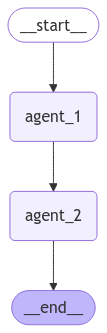

In [18]:
graph_0